#  Клиенты банка

**Набор данных о клиентах банка** — часть исследовательского проекта по анализу индийских финансовых данных и выявлению мошеннических операций.

Цель данного ноутбука — провести **разведочный анализ данных (EDA)** набора `Cusmtomer_data.csv`: изучить структуру данных, распределения признаков и связи между ними.

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("data/Cusmtomer_data.csv")
pd.set_option("display.float_format", "{:.2f}".format)

print(f"Количество строк {df.shape[0]}, количество столбцов {df.shape[1]}")
print("\n-----------------------")
print("Информация о типах данных")
print(df.info())
print("\n-----------------------")
print("Выборка первых записей")
print(df.head())
print("\n-----------------------")
print("Количество дубликатов")
print(df.duplicated().sum())
print("\n-----------------------")
print("Количество пропущенных значений")
print(df.isna().sum())
print("\n-----------------------")
print("распределение числовых данных")
print(df.describe())

Количество строк 25000, количество столбцов 12

-----------------------
Информация о типах данных
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Customer_ID       25000 non-null  str  
 1   Customer_Name     25000 non-null  str  
 2   Gender            25000 non-null  str  
 3   Age               25000 non-null  int64
 4   Marital_Status    25000 non-null  str  
 5   Occupation        25000 non-null  str  
 6   Annual_Income     25000 non-null  int64
 7   Customer_Segment  25000 non-null  str  
 8   State             25000 non-null  str  
 9   City              25000 non-null  str  
 10  Account_Type      25000 non-null  str  
 11  Customer_Since    25000 non-null  str  
dtypes: int64(2), str(10)
memory usage: 2.3 MB
None

-----------------------
Выборка первых записей
  Customer_ID        Customer_Name  Gender  Age Marital_Status  \
0  CUST1

## Итоги EDA 

Датасет содержит **25 000** записей и **12 признаков** 

Дубликаты и пропущенные значения отсутствуют. 2 признака являются числовыми - **Age** и **Annual_Income**, **Customer_ID** и **Customer_Name** представляет собой технический параметр и идентификатор соответсвенно, они не представляют особого интереса для исследования. Остальные признаки являются категориальными или датами. 

Особое внимание следует уделить Occupation и Annual_Income. Необходимо исследовать распределение годового дохода и его взаимосвязи с другими признаками. Это позволит выявить потенциальные аномалии и несоответствия между характеристиками клиентов, которые в дальнейшем могут использоваться при построении модели обнаружения мошеннических операций.

### Потенциальный план для исследования:
1. Изучить взаимосвязь дохода и других признаков
2. Изучить взаимосвязь распределение профессий по городам и штатам, возрасту, полу, семейному статусу, типу учетной записи, пользовательскому сегменту

Остальные же признаки будут анализировать лишь по мере необходимости 

## Взаимосвязь дохода с другими признакми 

Для начала необходимо проверить данные на наличие выбросов и аномалий, затем проверю распределение доходов по профессиям 

In [3]:
Q1 = df["Annual_Income"].quantile(0.25)
Q3 = df["Annual_Income"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")

outliers = df[
    (df["Annual_Income"] < lower_bound) |
    (df["Annual_Income"] > upper_bound)
]

print(f"Количество выбросов: {len(outliers)}")
print(f"Доля выбросов: {len(outliers) / len(df) * 100:.2f}%")

print("\nНаименьшие значения среди выбросов:")
print(outliers["Annual_Income"].sort_values().head())

print("\nНаибольшие значения среди выбросов:")
print(outliers["Annual_Income"].sort_values(ascending=False).head())

Q1: 570477.50
Q3: 1882414.00
IQR: 1311936.50
Нижняя граница: -1397427.25
Верхняя граница: 3850318.75
Количество выбросов: 2468
Доля выбросов: 9.87%

Наименьшие значения среди выбросов:
7808     3850519
18305    3851795
24240    3852527
9683     3853920
12019    3854354
Name: Annual_Income, dtype: int64

Наибольшие значения среди выбросов:
8311     9999931
2998     9992370
22595    9985849
12633    9984693
13576    9981000
Name: Annual_Income, dtype: int64


In [4]:
outliers["Occupation"].value_counts()

Occupation
Business                1377
Doctor                   611
Chartered Accountant     364
Lawyer                   116
Name: count, dtype: int64

In [5]:
outliers["Occupation"].value_counts(normalize=True) * 100

Occupation
Business               55.79
Doctor                 24.76
Chartered Accountant   14.75
Lawyer                  4.70
Name: proportion, dtype: float64

In [6]:
df["Occupation"].value_counts(normalize=True) * 100

Occupation
Data Analyst           8.60
Lawyer                 8.51
Government Employee    8.50
Teacher                8.47
Farmer                 8.46
Police Officer         8.42
Business               8.30
Nurse                  8.24
Chartered Accountant   8.20
Student                8.18
Software Engineer      8.18
Doctor                 7.95
Name: proportion, dtype: float64

На профессию **Business** приходятся самые высокие зарплаты

In [ ]:
occupation_outliers = (
    outliers["Occupation"].value_counts().to_frame("Outliers")
)

occupation_total = (
    df["Occupation"].value_counts().to_frame("Total")
)

occupation_analysis = occupation_total.join(occupation_outliers).fillna(0)

occupation_analysis["Outliner_Rate"] = (
    occupation_analysis["Outliers"] / occupation_analysis["Total"] * 100
)

occupation_analysis.sort_values(
    "Outliner_Rate", ascending=False
)

,Total,Outliers,Outliner_Rate
Occupation,,,
Business,2075,1377.00,66.36
Doctor,1987,611.00,30.75
Chartered Accountant,2049,364.00,17.76
Lawyer,2128,116.00,5.45
Teacher,2118,0.00,0.00
Government Employee,2124,0.00,0.00
Data Analyst,2149,0.00,0.00
Farmer,2115,0.00,0.00
Nurse,2060,0.00,0.00


In [8]:
df.groupby("Occupation")["Annual_Income"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).sort_values("median", ascending=False)

,count,mean,median,std,min,max
Occupation,,,,,,
Business,2075,5378859.44,5315372.00,2668324.65,806486,9999931
Doctor,1987,3119395.00,3135340.00,1108022.48,1200072,4994790
Chartered Accountant,2049,2610920.02,2647533.00,1105606.79,700221,4498602
Lawyer,2128,2355072.91,2321508.00,968487.49,701807,3999921
Software Engineer,2044,1189208.26,1199097.00,347422.15,601782,1798188
Data Analyst,2149,1135107.18,1145263.00,372717.15,500017,1799827
Government Employee,2124,1090720.66,1094889.00,399082.77,400259,1799803
Police Officer,2105,807093.35,807123.00,233775.30,400451,1199891
Teacher,2118,601962.57,597252.50,173378.75,300565,899906


Выбросы **Annual_Income** представлены неравномерно, значительная часть (более **66%**) приходится **Business**, далее идут профессии **Doctor**, на которую приходится уже более **30%**, Chartered Accountant с **17.76%** и **Lawyer**, на которую приходится почти **5.5%**. Для остальных профессий значения выше глобальной IQR-границы отсутствуют

Анализ медианных зарплат показывает сильный разрыв между доходами в зависимости от профессианальной деятельности. Наиболее высокая медианная зарплата у **Business** в размере **5315372.00**, а наименьшая у **Student** в размере **97068.00** соответсвенно

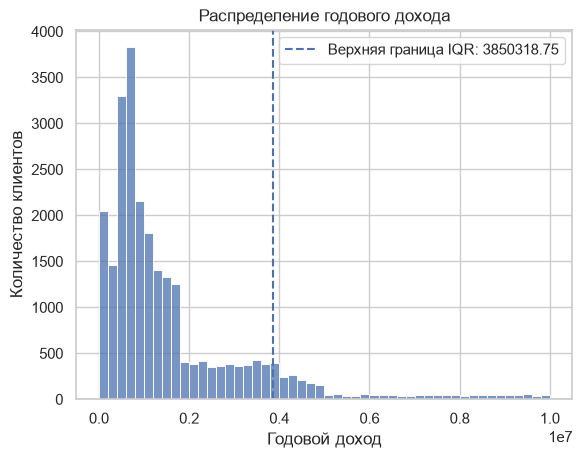

In [11]:
sns.histplot(data=df, x="Annual_Income", bins=50)

plt.axvline (
    upper_bound, 
    linestyle="--",
    label=f"Верхняя граница IQR: {upper_bound}"
)

plt.xlabel("Годовой доход"),
plt.ylabel("Количество клиентов"),
plt.title("Распределение годового дохода")
plt.legend()
plt.show()

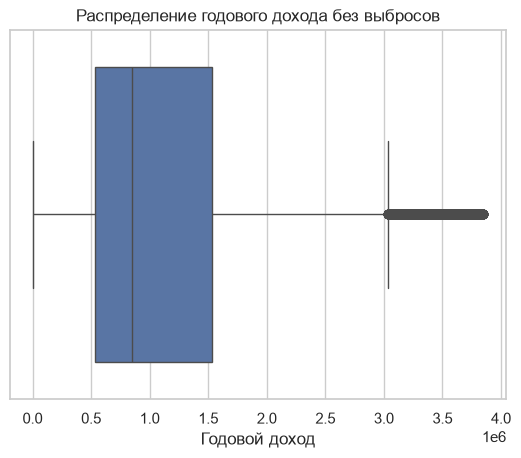

In [15]:
sns.boxplot(data=df[df["Annual_Income"] <= upper_bound], x="Annual_Income")

plt.xlabel("Годовой доход")
plt.title("Распределение годового дохода без выбросов")
plt.show()